# Projeto IA - Unidade 1
## Dia 5: Modelagem Supervisionada (Classificação)

Neste notebook, treinaremos 6 algoritmos de classificação no dataset **Breast Cancer Wisconsin** (diagnóstico binário: Benigno vs Maligno). 
Avaliaremos o desempenho usando Matrizes de Confusão e as métricas obrigatórias: Acurácia, Precisão, Recall, F1-Score e ROC-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# Pré-processamento
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Métricas de Avaliação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

sns.set_theme(style="whitegrid")

### 1. Preparando os Dados
Carregamento, divisão estratificada (preservando a proporção biológica de tumores) e padronização geométrica (StandardScaler).

In [2]:
# Carregar dataset
data = load_breast_cancer()
X = data.data
y = data.target  # 0: Malignant, 1: Benign

# Divisão Treino/Teste (80/20) com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronização (Crucial para SVC, Logistic Regression e MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dados Prontos! Treino: {X_train_scaled.shape}, Teste: {X_test_scaled.shape}")

Dados Prontos! Treino: (455, 30), Teste: (114, 30)


### 2. Instanciando os 6 Modelos Obrigatórios
Notas técnicas importantes:
- `SVC(probability=True)`: Necessário para calcular a curva ROC-AUC, que exige probabilidades contínuas, não apenas classes (0 ou 1).
- `MLPClassifier(max_iter=1000)`: Limite de épocas aumentado para garantir convergência na descida do gradiente.

In [3]:
modelos = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    "SVC": SVC(random_state=42, probability=True), # probability=True para o ROC-AUC
    "MLP (Rede Neural)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

### 3. Treinamento e Avaliação
Iterando sobre os algoritmos para extrair: Acurácia, Precisão, Recall, F1-Score, ROC-AUC e Tempo de Treinamento.

In [ ]:
resultados = []
matrizes_confusao = {}
probabilidades_roc = {}

print("Iniciando treinamento...")

for nome, modelo in modelos.items():
    # Treino com cronômetro
    start_time = time()
    modelo.fit(X_train_scaled, y_train)
    tempo_treino = time() - start_time
    
    # Predições absolutas (0 ou 1)
    y_pred = modelo.predict(X_test_scaled)
    
    # Predições de probabilidade (necessário para ROC-AUC)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    probabilidades_roc[nome] = y_prob
    
    # Armazenar Matriz de Confusão
    matrizes_confusao[nome] = confusion_matrix(y_test, y_pred)
    
    # Calcular Métricas (Assumindo a classe padrão 1 como Benigno, e 0 como Maligno)
    # OBS: O dataset da Sklearn usa 0=Maligno, 1=Benigno.
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    resultados.append({
        "Modelo": nome,
        "Acurácia": acc,
        "Precisão": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Tempo (s)": round(tempo_treino, 4)
    })

print("Treinamento concluído!")

### 4. Tabela de Resultados Comparativos

In [5]:
df_resultados = pd.DataFrame(resultados)

# Ordenar pelo melhor F1-Score (A melhor métrica balanceada para o mundo médico)
df_resultados = df_resultados.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_resultados)

,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC,Tempo (s)
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370,0.0395
1,SVC,0.982456,0.986111,0.986111,0.986111,0.995040,0.0775
2,XGBoost,0.956140,0.946667,0.986111,0.965986,0.992725,0.6670
3,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993882,0.5418
4,MLP (Rede Neural),0.947368,0.985294,0.930556,0.957143,0.994378,1.5587
5,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675,0.0186


### 5. Visualização das Matrizes de Confusão
As matrizes revelam exatamente ONDE o modelo está errando (Falso Positivo vs Falso Negativo).

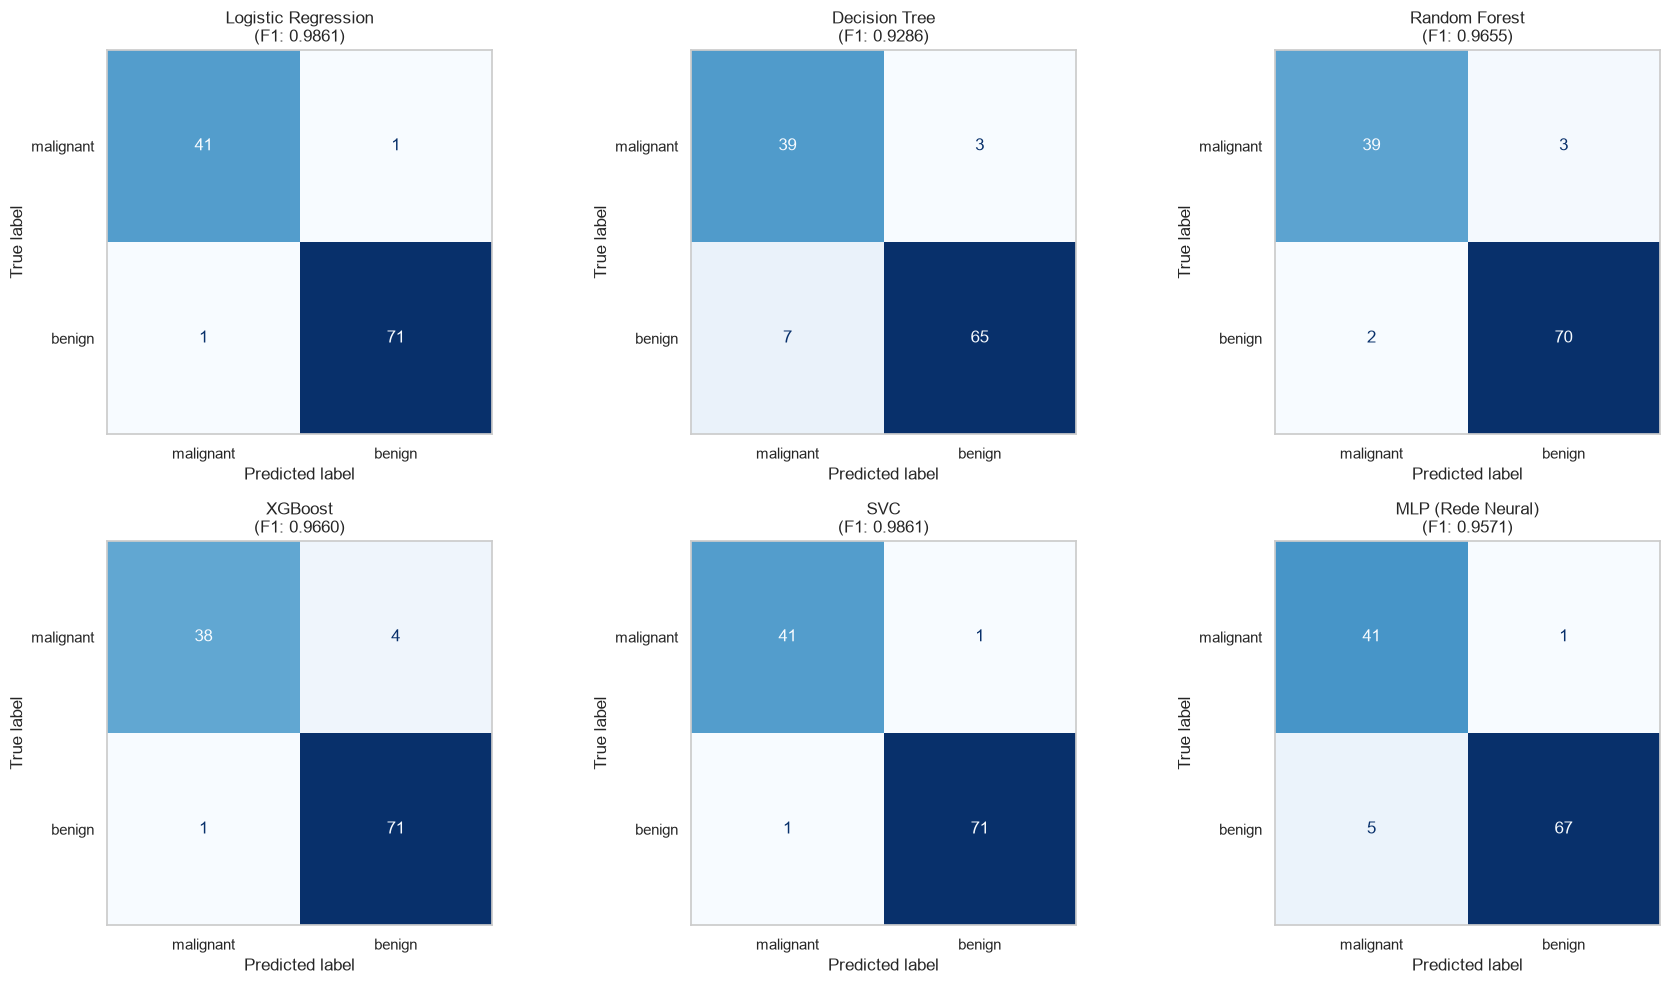

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (nome, cm) in enumerate(matrizes_confusao.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{nome}\n(F1: {df_resultados[df_resultados["Modelo"]==nome]["F1-Score"].values[0]:.4f})')
    axes[idx].grid(False) # Remover gridlines chatas de fundo

plt.tight_layout()
plt.show()

### 6. Curva ROC (Receiver Operating Characteristic)
Mostra a capacidade dos modelos em separar matematicamente a classe Maligna da Benigna. Quanto mais a curva abraça o canto superior esquerdo, melhor.

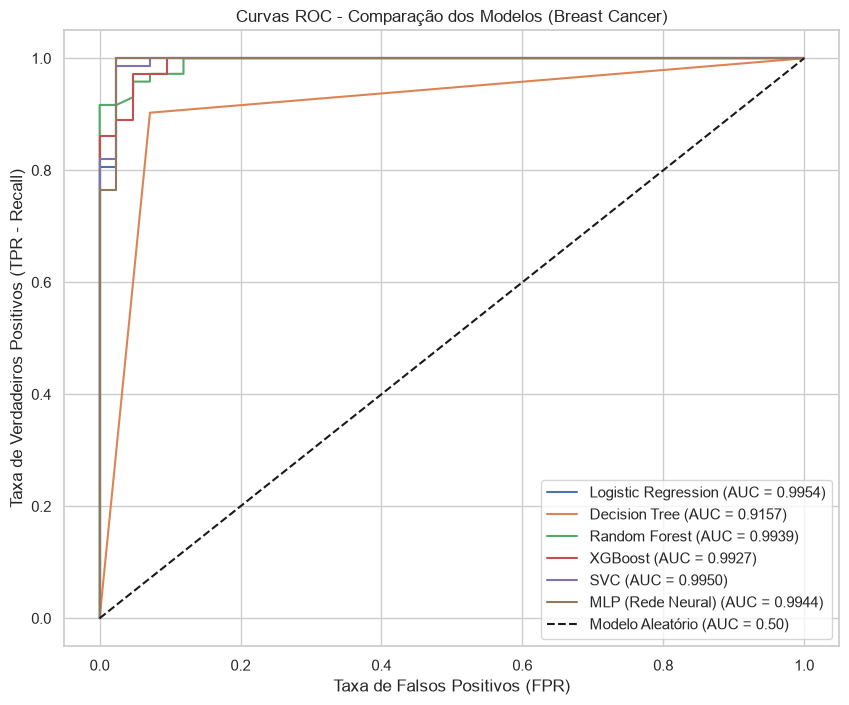

In [7]:
plt.figure(figsize=(10, 8))

for nome in modelos.keys():
    # Extrair AUC da tabela final para a legenda
    auc = df_resultados[df_resultados['Modelo'] == nome]['ROC-AUC'].values[0]
    
    # Calcular Taxa de Falsos Positivos (FPR) e Taxa de Verdadeiros Positivos (TPR)
    fpr, tpr, _ = roc_curve(y_test, probabilidades_roc[nome])
    
    # Plotar a linha do modelo
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc:.4f})")

# Plotar a linha diagonal de "chute aleatório"
plt.plot([0, 1], [0, 1], 'k--', label="Modelo Aleatório (AUC = 0.50)")

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR - Recall)")
plt.title("Curvas ROC - Comparação dos Modelos (Breast Cancer)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()